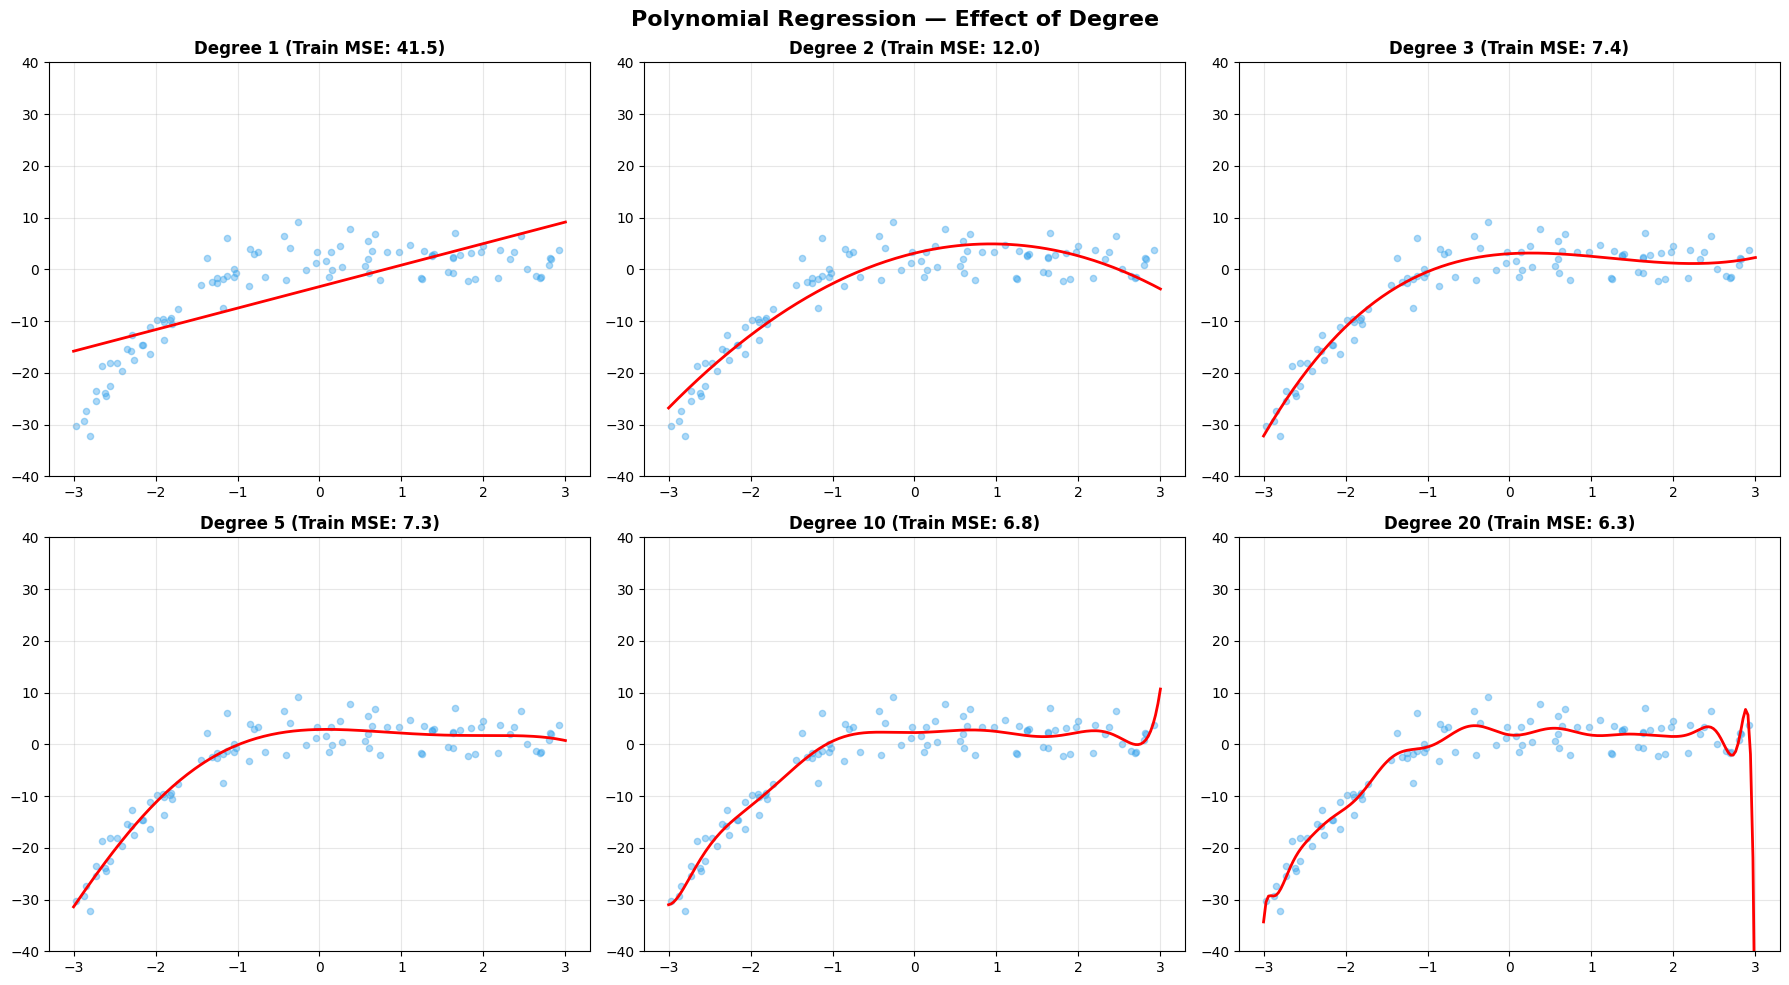

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Generate non-linear data
np.random.seed(42)
X = np.sort(np.random.uniform(-3, 3, 100)).reshape(-1, 1)
y = 0.5 * X.ravel()**3 - 2 * X.ravel()**2 + X.ravel() + 3 + np.random.randn(100) * 3

# Fit polynomials of different degrees
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
degrees = [1, 2, 3, 5, 10, 20]
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

for ax, degree in zip(axes.flat, degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    y_pred = model.predict(X_plot)
    train_mse = mean_squared_error(y, model.predict(X))
    
    ax.scatter(X, y, alpha=0.4, s=20, color='#36A2EB')
    ax.plot(X_plot, y_pred, 'r-', linewidth=2)
    ax.set_title(f'Degree {degree} (Train MSE: {train_mse:.1f})', fontsize=12, fontweight='bold')
    ax.set_ylim(-40, 40)
    ax.grid(True, alpha=0.3)

plt.suptitle('Polynomial Regression — Effect of Degree', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('polynomial_degrees.png', dpi=150)
plt.show()

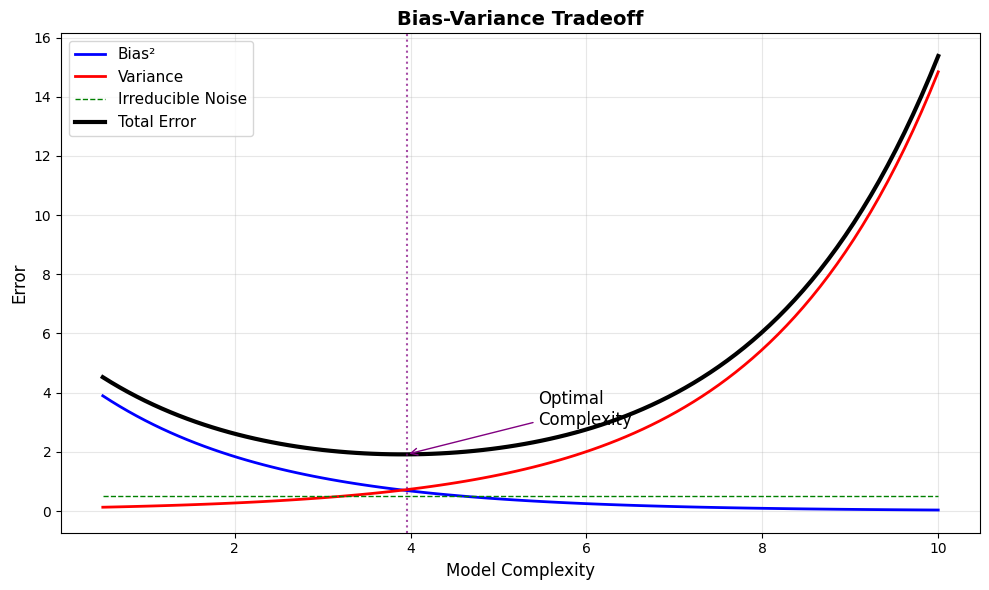

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize bias-variance tradeoff
complexity = np.linspace(0.5, 10, 100)
bias_squared = 5 * np.exp(-0.5 * complexity)
variance = 0.1 * np.exp(0.5 * complexity)
noise = np.ones_like(complexity) * 0.5
total_error = bias_squared + variance + noise

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(complexity, bias_squared, 'b-', linewidth=2, label='Bias²')
ax.plot(complexity, variance, 'r-', linewidth=2, label='Variance')
ax.plot(complexity, noise, 'g--', linewidth=1, label='Irreducible Noise')
ax.plot(complexity, total_error, 'k-', linewidth=3, label='Total Error')

# Mark optimal complexity
min_idx = np.argmin(total_error)
ax.axvline(complexity[min_idx], color='purple', linestyle=':', alpha=0.7)
ax.annotate('Optimal\nComplexity', xy=(complexity[min_idx], total_error[min_idx]),
            xytext=(complexity[min_idx]+1.5, total_error[min_idx]+1),
            fontsize=12, arrowprops=dict(arrowstyle='->', color='purple'))

ax.set_xlabel('Model Complexity', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Bias-Variance Tradeoff', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bias_variance.png', dpi=150)
plt.show()

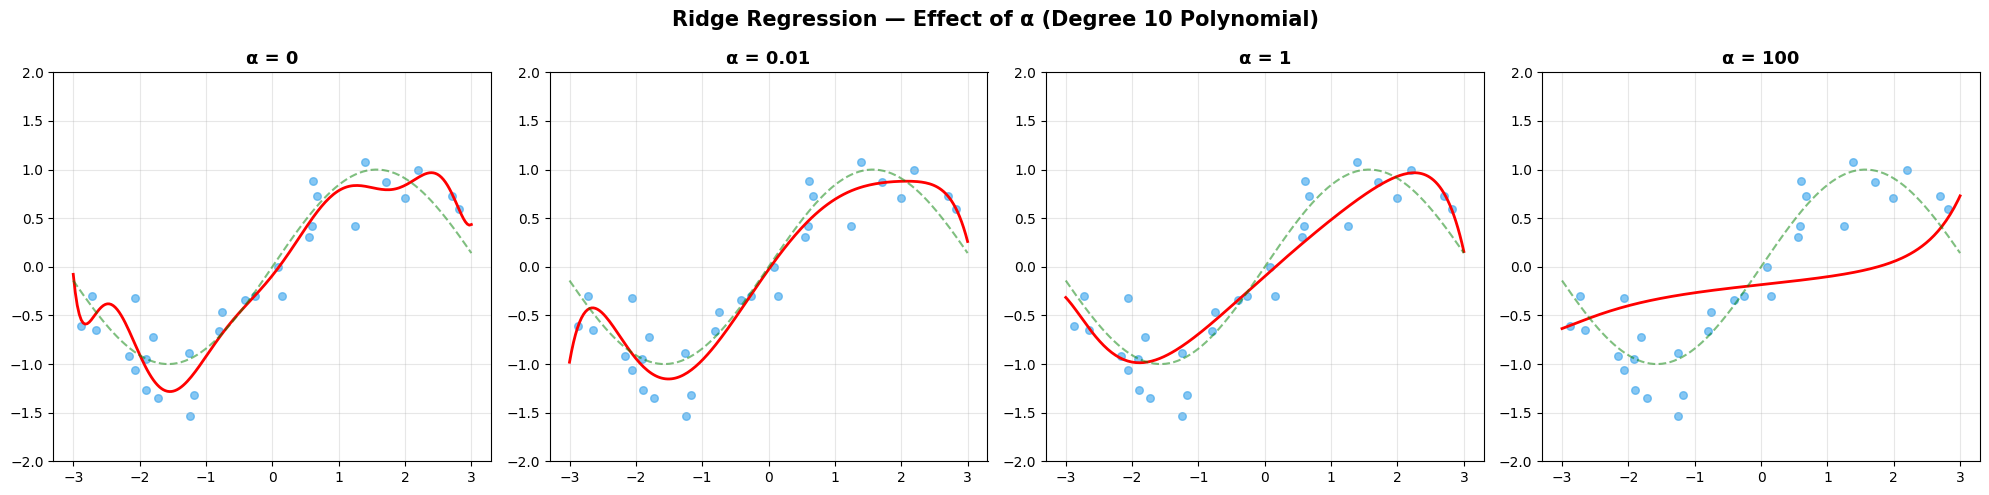

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)
X = np.sort(np.random.uniform(-3, 3, 30)).reshape(-1, 1)
y = np.sin(X.ravel()) + np.random.randn(30) * 0.3
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
alphas = [0, 0.01, 1, 100]

for ax, alpha in zip(axes, alphas):
    model = make_pipeline(
        PolynomialFeatures(10),
        StandardScaler(),
        Ridge(alpha=alpha)
    )
    model.fit(X, y)
    y_pred = model.predict(X_plot)
    
    ax.scatter(X, y, alpha=0.6, s=30, color='#36A2EB')
    ax.plot(X_plot, y_pred, 'r-', linewidth=2)
    ax.plot(X_plot, np.sin(X_plot.ravel()), 'g--', alpha=0.5, label='True')
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold')
    ax.set_ylim(-2, 2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Ridge Regression — Effect of α (Degree 10 Polynomial)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('ridge_alpha.png', dpi=150)
plt.show()

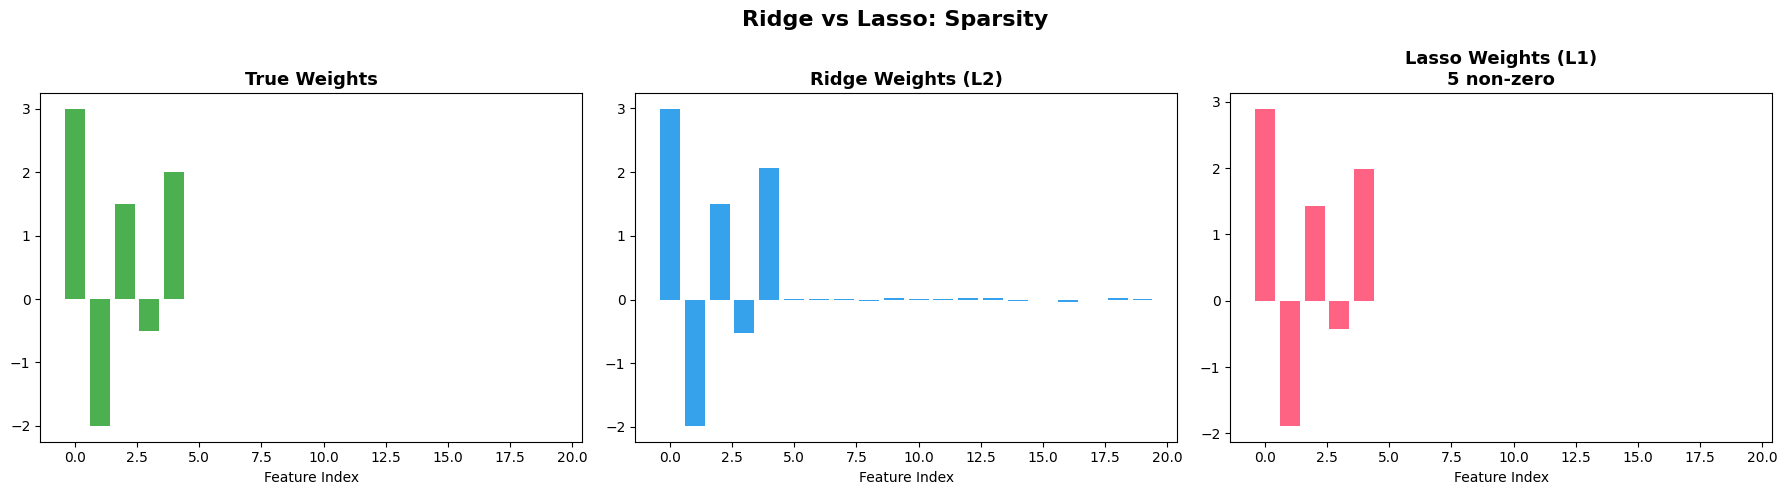

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge

# Create data with many features but only a few are relevant
np.random.seed(42)
n_features = 20
X = np.random.randn(200, n_features)
true_weights = np.zeros(n_features)
true_weights[:5] = [3, -2, 1.5, -0.5, 2]  # Only 5 features matter!
y = X @ true_weights + np.random.randn(200) * 0.5

# Compare Ridge vs Lasso
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True weights
axes[0].bar(range(n_features), true_weights, color='#4CAF50')
axes[0].set_title('True Weights', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature Index')

# Ridge weights
ridge = Ridge(alpha=1.0)
ridge.fit(X, y)
axes[1].bar(range(n_features), ridge.coef_, color='#36A2EB')
axes[1].set_title('Ridge Weights (L2)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature Index')

# Lasso weights
lasso = Lasso(alpha=0.1)
lasso.fit(X, y)
axes[2].bar(range(n_features), lasso.coef_, color='#FF6384')
axes[2].set_title(f'Lasso Weights (L1)\n{np.sum(lasso.coef_ != 0)} non-zero', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Feature Index')

plt.suptitle('Ridge vs Lasso: Sparsity', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ridge_vs_lasso.png', dpi=150)
plt.show()

In [5]:
from sklearn.linear_model import ElasticNet, ElasticNetCV
import numpy as np

np.random.seed(42)
X = np.random.randn(200, 20)
true_w = np.zeros(20)
true_w[:5] = [3, -2, 1.5, -0.5, 2]
y = X @ true_w + np.random.randn(200) * 0.5

# ElasticNet with cross-validation to find best alpha and l1_ratio
enet_cv = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
                        alphas=np.logspace(-4, 1, 50),
                        cv=5, random_state=42)
enet_cv.fit(X, y)

print(f"Best alpha:    {enet_cv.alpha_:.6f}")
print(f"Best l1_ratio: {enet_cv.l1_ratio_}")
print(f"Non-zero coefficients: {np.sum(enet_cv.coef_ != 0)}/{len(enet_cv.coef_)}")
print(f"R² score: {enet_cv.score(X, y):.4f}")

Best alpha:    0.035565
Best l1_ratio: 1.0
Non-zero coefficients: 5/20
R² score: 0.9876


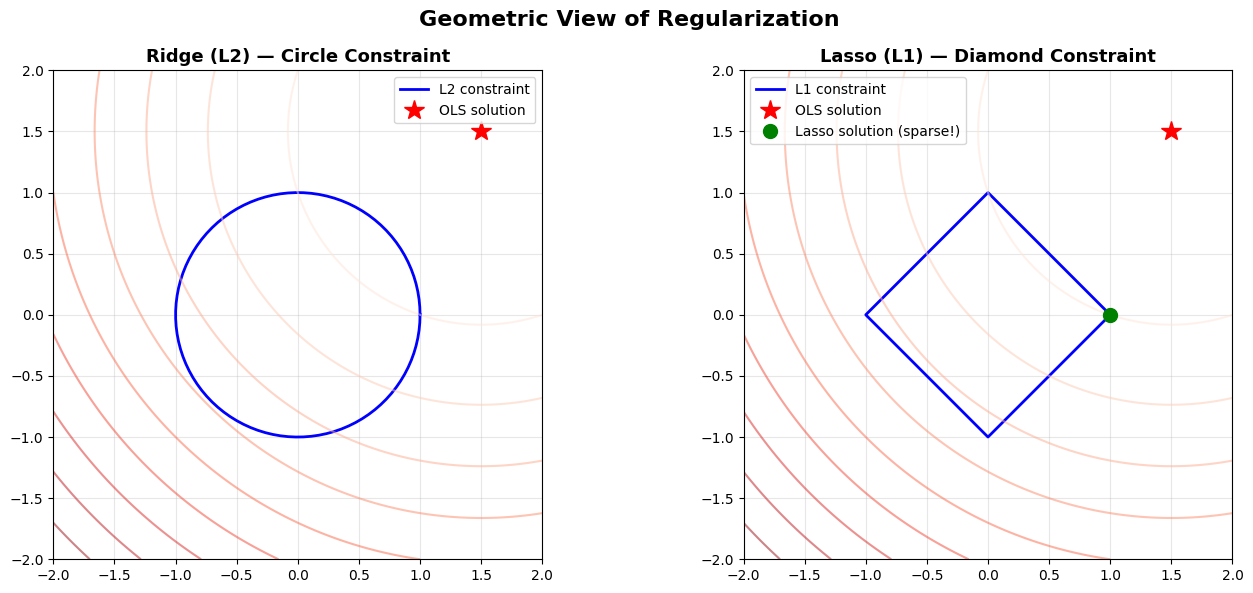

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# L2 constraint (circle)
theta = np.linspace(0, 2*np.pi, 100)
axes[0].plot(np.cos(theta), np.sin(theta), 'b-', linewidth=2, label='L2 constraint')
# Add contours of loss function
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X_mesh, Y_mesh = np.meshgrid(x, y)
Z = (X_mesh - 1.5)**2 + (Y_mesh - 1.5)**2
axes[0].contour(X_mesh, Y_mesh, Z, levels=10, cmap='Reds', alpha=0.5)
axes[0].plot(1.5, 1.5, 'r*', markersize=15, label='OLS solution')
axes[0].set_title('Ridge (L2) — Circle Constraint', fontsize=13, fontweight='bold')
axes[0].set_aspect('equal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-2, 2)

# L1 constraint (diamond)
diamond_x = [1, 0, -1, 0, 1]
diamond_y = [0, 1, 0, -1, 0]
axes[1].plot(diamond_x, diamond_y, 'b-', linewidth=2, label='L1 constraint')
axes[1].contour(X_mesh, Y_mesh, Z, levels=10, cmap='Reds', alpha=0.5)
axes[1].plot(1.5, 1.5, 'r*', markersize=15, label='OLS solution')
axes[1].plot(1, 0, 'go', markersize=10, label='Lasso solution (sparse!)')
axes[1].set_title('Lasso (L1) — Diamond Constraint', fontsize=13, fontweight='bold')
axes[1].set_aspect('equal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-2, 2)
axes[1].set_ylim(-2, 2)

plt.suptitle('Geometric View of Regularization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('regularization_geometry.png', dpi=150)
plt.show()

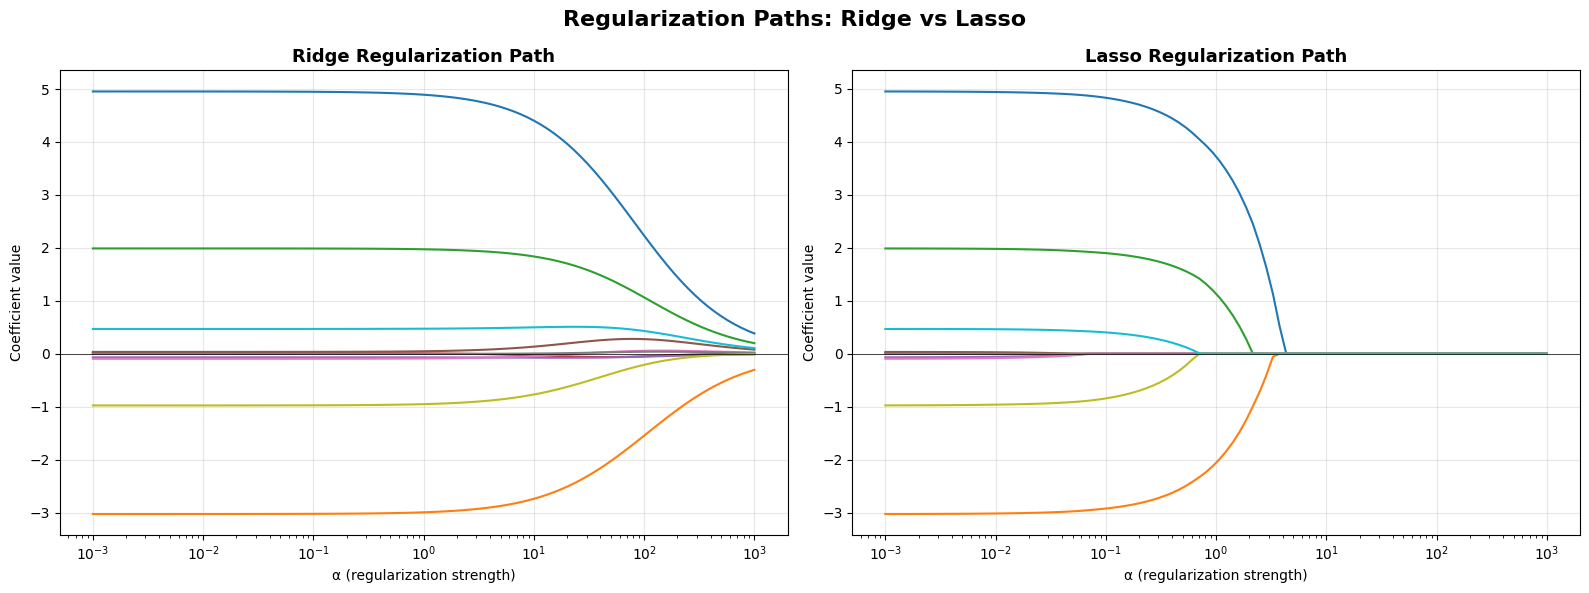

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge

np.random.seed(42)
X = np.random.randn(100, 10)
true_w = np.array([5, -3, 2, 0, 0, 0, 0, 0, -1, 0.5])
y = X @ true_w + np.random.randn(100) * 0.5

alphas = np.logspace(-3, 3, 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ridge path
ridge_coefs = []
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X, y)
    ridge_coefs.append(model.coef_)
ridge_coefs = np.array(ridge_coefs)

for i in range(10):
    axes[0].plot(alphas, ridge_coefs[:, i], linewidth=1.5, label=f'w{i}')
axes[0].set_xscale('log')
axes[0].set_xlabel('α (regularization strength)')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('Ridge Regularization Path', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.5)

# Lasso path
lasso_coefs = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X, y)
    lasso_coefs.append(model.coef_)
lasso_coefs = np.array(lasso_coefs)

for i in range(10):
    axes[1].plot(alphas, lasso_coefs[:, i], linewidth=1.5, label=f'w{i}')
axes[1].set_xscale('log')
axes[1].set_xlabel('α (regularization strength)')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('Lasso Regularization Path', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('Regularization Paths: Ridge vs Lasso', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('regularization_path.png', dpi=150)
plt.show()

In [8]:
import numpy as np

class RidgeRegressionFromScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.weights = None
        self.bias = None
    
    def fit(self, X, y):
        n, p = X.shape
        # Add bias column
        X_b = np.c_[np.ones(n), X]
        # Ridge closed-form: θ = (X^T X + αI)^{-1} X^T y
        I = np.eye(p + 1)
        I[0, 0] = 0  # Don't regularize the bias!
        self.theta = np.linalg.inv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y
        self.bias = self.theta[0]
        self.weights = self.theta[1:]
        return self
    
    def predict(self, X):
        return X @ self.weights + self.bias

# Test
np.random.seed(42)
X = np.random.randn(100, 5)
y = X @ np.array([3, -1, 2, 0, 0.5]) + 1 + np.random.randn(100) * 0.3

ridge = RidgeRegressionFromScratch(alpha=1.0)
ridge.fit(X, y)
print(f"Weights: {ridge.weights.round(3)}")
print(f"Bias: {ridge.bias:.3f}")

Weights: [ 2.98  -0.952  1.974  0.044  0.49 ]
Bias: 0.952
